# Mini GPT-2 구현
2023240419 손찬영

- 데이터셋: Alice in Wonderland
- 구조: decoder-only Transformer (GPT-2 핵심 구조)
- 실험: small / medium 두 가지 하이퍼파라미터 비교

- 입력 x = [t1, t2, ..., tT]
- 타깃 y = [t2, t3, ..., t(T+1)] (1칸 shift)
- 모든 시간축 위치에서 next token 예측
- CrossEntropyLoss

## 0. 런타임 설정 확인
**반드시 먼저:** 런타임 → 런타임 유형 변경 → **T4 GPU** 선택 후 저장

In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')
if device == 'cpu':
    print('⚠️  GPU가 연결되지 않았습니다. 런타임 → 런타임 유형 변경 → T4 GPU 선택하세요.')
else:
    print('✅ GPU 연결됨 — 빠르게 학습됩니다.')

device: cuda
✅ GPU 연결됨 — 빠르게 학습됩니다.


## 1. 데이터 다운로드 — Alice in Wonderland

In [2]:
import urllib.request
from pathlib import Path

if not Path('input.txt').exists():
    print('Alice in Wonderland 다운로드 중...')
    urllib.request.urlretrieve(
        'https://www.gutenberg.org/files/11/11-0.txt',
        'input.txt'
    )
    print('완료!')
else:
    print('input.txt 이미 존재')

text = open('input.txt', 'r', encoding='utf-8').read()
print(f'텍스트 길이: {len(text):,}자')
print('--- 앞부분 미리보기 ---')
print(text[1000:1300])

Alice in Wonderland 다운로드 중...
완료!
텍스트 길이: 144,696자
--- 앞부분 미리보기 ---
 own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.

There was nothing so _very_ remarkable


## 2. 문자 단위 토큰화

In [3]:
import torch

chars      = sorted(list(set(text)))
vocab_size = len(chars)
stoi       = {ch: i for i, ch in enumerate(chars)}
itos       = {i: ch for i, ch in enumerate(chars)}
encode     = lambda s: [stoi[c] for c in s]
decode     = lambda l: ''.join([itos[i] for i in l])

print(f'vocab_size: {vocab_size}')
print(f'문자 예시: {chars[:10]}')

# 전체 텍스트를 정수 텐서로 변환
data = torch.tensor(encode(text), dtype=torch.long)
n    = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f'train: {len(train_data):,}토큰 | val: {len(val_data):,}토큰')

vocab_size: 76
문자 예시: ['\n', ' ', '!', '(', ')', '*', ',', '-', '.', '0']
train: 130,226토큰 | val: 14,470토큰


## 3. Dataset — x/y 1칸 shift

```
입력 x = [t1, t2, t3, t4]
타깃 y = [t2, t3, t4, t5]  ← 1칸 오른쪽 shift
```

In [4]:
from torch.utils.data import Dataset, DataLoader

class NextTokenDataset(Dataset):
    """
    학교 과제 요구사항 Dataset.
    x = [t1, t2, ..., tT]
    y = [t2, t3, ..., t(T+1)]  (1칸 shift)
    """
    def __init__(self, data, block_size):
        self.data       = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx     : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]  # 1칸 shift
        return x, y

# 확인
tmp_ds = NextTokenDataset(data, block_size=8)
x, y = tmp_ds[0]
print('x:', decode(x.tolist()))
print('y:', decode(y.tolist()))
print('x.shape:', x.shape, '| y.shape:', y.shape)

x: *** STAR
y: ** START
x.shape: torch.Size([8]) | y.shape: torch.Size([8])


## 4. 모델 구조 — GPT-2 핵심 구조

In [5]:
import torch.nn as nn
from torch.nn import functional as F

class Head(nn.Module):
    """단일 self-attention head (causal mask 포함)"""
    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # causal mask: 미래 토큰을 보지 못하게 하는 하삼각행렬
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v


class MultiHeadAttention(nn.Module):
    """여러 head를 병렬로 실행하는 multi-head attention"""
    def __init__(self, n_embd, num_heads, head_size, block_size, dropout):
        super().__init__()
        self.heads   = nn.ModuleList([
            Head(n_embd, head_size, block_size, dropout) for _ in range(num_heads)
        ])
        self.proj    = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    """Position-wise FFN — GELU 활성화 (GPT-2 논문 방식, Notebook 6의 ReLU에서 변경)"""
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Transformer Block: Pre-LN → Attention → Residual → Pre-LN → FFN → Residual"""
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_embd, n_head, head_size, block_size, dropout)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))    # residual connection
        x = x + self.ffwd(self.ln2(x))  # residual connection
        return x


class GPTLanguageModel(nn.Module):
    """
    GPT-2 핵심 구조: decoder-only Transformer
    입력:  (B, T) 정수 토큰
    출력:  logits (B, T, vocab_size), loss
    """
    def __init__(self, vocab_size, block_size, n_embd, n_head, n_layer, dropout):
        super().__init__()
        self.block_size = block_size
        self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks  = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f    = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)                       # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))  # (T,C)
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)                                        # (B,T,vocab_size)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits    = logits[:, -1, :]
            probs     = F.softmax(logits, dim=-1)
            idx_next  = torch.multinomial(probs, num_samples=1)
            idx       = torch.cat((idx, idx_next), dim=1)
        return idx

print('모델 클래스 정의 완료')

모델 클래스 정의 완료


## 5. 학습 함수

In [6]:
def get_batch(data, block_size, batch_size):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x  = torch.stack([data[i : i + block_size]     for i in ix])
    y  = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss(model, block_size, batch_size, eval_iters=50):
    model.eval()
    out = {}
    for split, d in [('train', train_data), ('val', val_data)]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(d, block_size, batch_size)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

print('학습 함수 정의 완료')

학습 함수 정의 완료


## 6. 실험 1 — Small 모델 학습
GPU 기준 약 2~3분

In [7]:
torch.manual_seed(1337)

EXP_SMALL = {
    'name':          'small',
    'batch_size':    16,
    'block_size':    64,
    'max_iters':     1000,
    'eval_interval': 200,
    'n_embd':        64,
    'n_head':        4,
    'n_layer':       4,
    'dropout':       0.1,
    'lr':            1e-3,
}

model_small = GPTLanguageModel(
    vocab_size  = vocab_size,
    block_size  = EXP_SMALL['block_size'],
    n_embd      = EXP_SMALL['n_embd'],
    n_head      = EXP_SMALL['n_head'],
    n_layer     = EXP_SMALL['n_layer'],
    dropout     = EXP_SMALL['dropout'],
).to(device)

print(f"파라미터 수: {sum(p.numel() for p in model_small.parameters()):,}")

optimizer_small = torch.optim.AdamW(model_small.parameters(), lr=EXP_SMALL['lr'])
loss_log_small  = []

for it in range(EXP_SMALL['max_iters'] + 1):
    if it % EXP_SMALL['eval_interval'] == 0:
        losses = estimate_loss(model_small, EXP_SMALL['block_size'], EXP_SMALL['batch_size'])
        log = f"[small] step {it:4d} | train {losses['train']:.4f} | val {losses['val']:.4f}"
        print(log)
        loss_log_small.append(log)
    if it == EXP_SMALL['max_iters']:
        break
    xb, yb  = get_batch(train_data, EXP_SMALL['block_size'], EXP_SMALL['batch_size'])
    _, loss = model_small(xb, yb)
    optimizer_small.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_small.step()

print('\nSmall 학습 완료!')

파라미터 수: 213,196
[small] step    0 | train 4.3553 | val 4.3555
[small] step  200 | train 2.4645 | val 2.4592
[small] step  400 | train 2.2977 | val 2.3081
[small] step  600 | train 2.1134 | val 2.1230
[small] step  800 | train 1.9873 | val 2.0068
[small] step 1000 | train 1.8828 | val 1.9340

Small 학습 완료!


## 7. Small 모델 — 텍스트 생성

In [8]:
ctx = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_small = decode(model_small.generate(ctx, max_new_tokens=500)[0].tolist())
print('=== Small 모델 생성 텍스트 ===')
print(generated_small)

=== Small 모델 생성 텍스트 ===

for whesh.

“Out ma lown ithe loddoned itle had it  poon, dowas che saages it_ litcerts att sleeep, notp, what Mhid. Sif spet it’s Alicers plobors said
manry in liten
primed a raw ond sthe
sor?” said shain.

Tha chaterselw “Soup ma thing peathen wond, byne: Quche the litrgen. She Quch Kourmbleant,

to she said and the chag for the she “Alice. The fling the (carck!le Tund head puchpp!”


“A ouxstenio thing the so hought, own trimntying to a lints this thif thing the own to she cur emauch Mopstis 


## 8. 실험 2 — Medium 모델 학습
GPU 기준 약 5~8분

In [9]:
EXP_MEDIUM = {
    'name':          'medium',
    'batch_size':    32,
    'block_size':    128,
    'max_iters':     2000,
    'eval_interval': 200,
    'n_embd':        128,
    'n_head':        4,
    'n_layer':       6,
    'dropout':       0.1,
    'lr':            5e-4,
}

model_medium = GPTLanguageModel(
    vocab_size  = vocab_size,
    block_size  = EXP_MEDIUM['block_size'],
    n_embd      = EXP_MEDIUM['n_embd'],
    n_head      = EXP_MEDIUM['n_head'],
    n_layer     = EXP_MEDIUM['n_layer'],
    dropout     = EXP_MEDIUM['dropout'],
).to(device)

print(f"파라미터 수: {sum(p.numel() for p in model_medium.parameters()):,}")

optimizer_medium = torch.optim.AdamW(model_medium.parameters(), lr=EXP_MEDIUM['lr'])
loss_log_medium  = []

for it in range(EXP_MEDIUM['max_iters'] + 1):
    if it % EXP_MEDIUM['eval_interval'] == 0:
        losses = estimate_loss(model_medium, EXP_MEDIUM['block_size'], EXP_MEDIUM['batch_size'])
        log = f"[medium] step {it:4d} | train {losses['train']:.4f} | val {losses['val']:.4f}"
        print(log)
        loss_log_medium.append(log)
    if it == EXP_MEDIUM['max_iters']:
        break
    xb, yb  = get_batch(train_data, EXP_MEDIUM['block_size'], EXP_MEDIUM['batch_size'])
    _, loss = model_medium(xb, yb)
    optimizer_medium.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_medium.step()

print('\nMedium 학습 완료!')

파라미터 수: 1,223,500
[medium] step    0 | train 4.3456 | val 4.3395
[medium] step  200 | train 2.4039 | val 2.4086
[medium] step  400 | train 2.1868 | val 2.2001
[medium] step  600 | train 1.8145 | val 1.8586
[medium] step  800 | train 1.6173 | val 1.6965
[medium] step 1000 | train 1.4738 | val 1.6075
[medium] step 1200 | train 1.3879 | val 1.5438
[medium] step 1400 | train 1.2885 | val 1.4905
[medium] step 1600 | train 1.2266 | val 1.4789
[medium] step 1800 | train 1.1581 | val 1.4481
[medium] step 2000 | train 1.1011 | val 1.4253

Medium 학습 완료!


## 9. Medium 모델 — 텍스트 생성

In [10]:
ctx = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_medium = decode(model_medium.generate(ctx, max_new_tokens=500)[0].tolist())
print('=== Medium 모델 생성 텍스트 ===')
print(generated_medium)

=== Medium 모델 생성 텍스트 ===

all learn, for the moment into something to whether) she hardn’s going back to
way: but the Queen asked almostly, as she should very like to go as she looked;
and it a gewer-cam to her voice the with the other was no remarkemtion. Alice fam
the long soldiers and both begin.

“It had _tawn,” their plaused, “and I much this graz’s, my what, all mad for fill nearn
the Marchmst spoks.

The Hatter were where lung fund she remark the notion into it;
notice to herself just he did not a bottle disbbit u


## 10. Loss 곡선 시각화 — small vs medium 비교

/tmp/ipykernel_2446/945714193.py:31: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2446/945714193.py:31: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2446/945714193.py:31: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2446/945714193.py:31: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2446/945714193.py:32: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2446/945714193.py:32: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2446/945714193.py:32: UserWarning: Glyph 

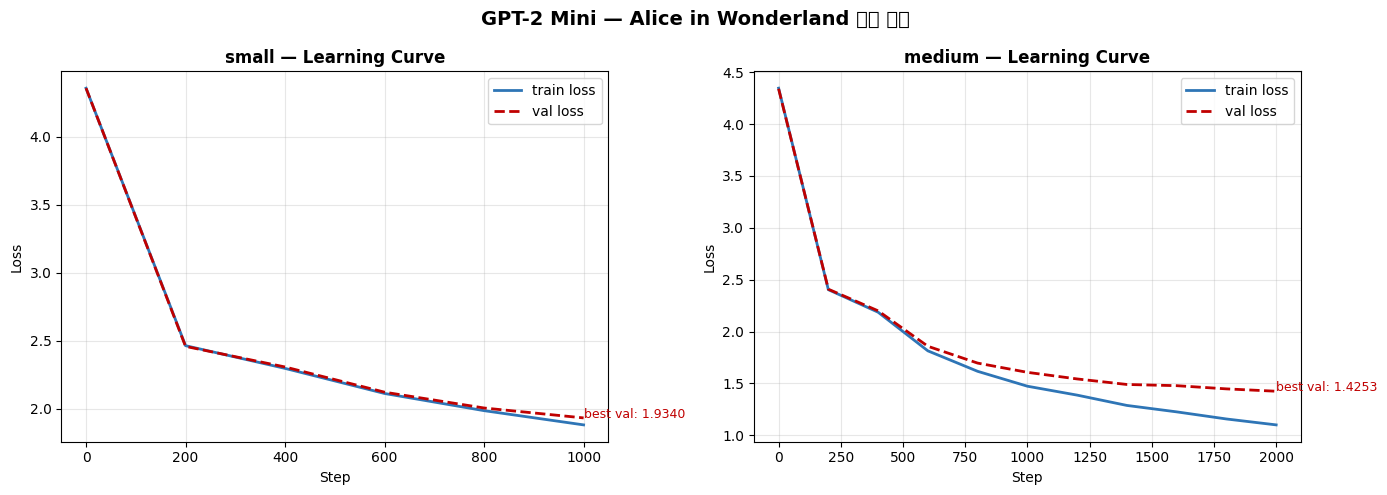

loss_curve.png 저장 완료


In [11]:
import re
import matplotlib.pyplot as plt

def parse_logs(logs):
    steps, train_losses, val_losses = [], [], []
    for line in logs:
        m = re.match(r'.* step\s+(\d+) \| train ([\d.]+) \| val ([\d.]+)', line)
        if m:
            steps.append(int(m.group(1)))
            train_losses.append(float(m.group(2)))
            val_losses.append(float(m.group(3)))
    return steps, train_losses, val_losses

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GPT-2 Mini — Alice in Wonderland 학습 결과', fontsize=14, fontweight='bold')

for ax, (name, logs) in zip(axes, [('small', loss_log_small), ('medium', loss_log_medium)]):
    steps, train_l, val_l = parse_logs(logs)
    ax.plot(steps, train_l, label='train loss', color='#2E75B6', linewidth=2)
    ax.plot(steps, val_l,   label='val loss',   color='#C00000', linewidth=2, linestyle='--')
    ax.set_title(f'{name} — Learning Curve', fontsize=12, fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if val_l:
        ax.annotate(f'best val: {min(val_l):.4f}',
                    xy=(steps[val_l.index(min(val_l))], min(val_l)),
                    fontsize=9, color='#C00000')

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('loss_curve.png 저장 완료')

## 11. 결과 파일 저장 (GitHub 제출용)

In [12]:
# loss_log.txt
with open('loss_log.txt', 'w', encoding='utf-8') as f:
    f.write('=== small ===\n')
    f.write('\n'.join(loss_log_small) + '\n\n')
    f.write('=== medium ===\n')
    f.write('\n'.join(loss_log_medium) + '\n\n')

# generated_sample.txt
with open('generated_sample.txt', 'w', encoding='utf-8') as f:
    f.write('=== small 생성 샘플 ===\n')
    f.write(generated_small + '\n\n')
    f.write('=== medium 생성 샘플 ===\n')
    f.write(generated_medium + '\n\n')

print('저장 완료!')
print('  loss_log.txt')
print('  generated_sample.txt')
print('  loss_curve.png')

저장 완료!
  loss_log.txt
  generated_sample.txt
  loss_curve.png


## 12. 파일 다운로드 (코랩 → 로컬)
아래 셀 실행하면 결과 파일들이 자동 다운로드됩니다.

In [13]:
from google.colab import files
files.download('loss_log.txt')
files.download('generated_sample.txt')
files.download('loss_curve.png')
print('다운로드 완료 — GitHub repo에 추가하세요!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드 완료 — GitHub repo에 추가하세요!
